Wine Quality Classification — Tech Challenge Fase 2
A indústria vitivinícola depende tradicionalmente de especialistas humanos para avaliar a qualidade dos vinhos, um processo caro, subjetivo e demorado. Com o avanço da ciência de dados e do aprendizado de máquina, tornou-se possível utilizar dados físico-químicos para prever a qualidade do vinho de forma automatizada.

Este notebook tem como objetivo desenvolver e avaliar modelos de Machine Learning capazes de classificar a qualidade de vinhos tintos com base em suas características físico-químicas, utilizando o Wine Quality Dataset disponível no Kaggle.


O problema foi tratado como uma classificação binária:

Alta Qualidade: nota ≥ 7 (1)
Baixa/Média Qualidade: nota < 7 (0)

As etapas seguidas foram:

1.Análise Exploratória dos Dados (EDA)

2.Pré-processamento e criação da variável alvo

3.Treinamento de dois modelos: Regressão Logística e Random Forest

4.Avaliação e comparação dos modelos

5.Interpretação dos resultados
---



In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [25]:
df = pd.read_csv('WineQT.csv')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


A análise exploratória tem como objetivo entender a distribuição dos dados, identificar correlações entre as variáveis e detectar possíveis outliers ou inconsistências

In [26]:
# Verificando o tamanho do dataset - linhas e colunas
print(df.shape)

(1143, 13)


In [27]:
# Verificando tipos de dados e valores nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [28]:
# Estatísticas básicas de cada variável
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1143.0,8.311111,1.747595,4.60000,7.10000,7.90000,9.100000,15.90000
volatile acidity,1143.0,0.531339,0.179633,0.12000,0.39250,0.52000,0.640000,1.58000
citric acid,1143.0,0.268364,0.196686,0.00000,0.09000,0.25000,0.420000,1.00000
residual sugar,1143.0,2.532152,1.355917,0.90000,1.90000,2.20000,2.600000,15.50000
chlorides,1143.0,0.086933,0.047267,0.01200,0.07000,0.07900,0.090000,0.61100
free sulfur dioxide,1143.0,15.615486,10.250486,1.00000,7.00000,13.00000,21.000000,68.00000
total sulfur dioxide,1143.0,45.914698,32.782130,6.00000,21.00000,37.00000,61.000000,289.00000
density,1143.0,0.996730,0.001925,0.99007,0.99557,0.99668,0.997845,1.00369
pH,1143.0,3.311015,0.156664,2.74000,3.20500,3.31000,3.400000,4.01000
sulphates,1143.0,0.657708,0.170399,0.33000,0.55000,0.62000,0.730000,2.00000


In [29]:
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


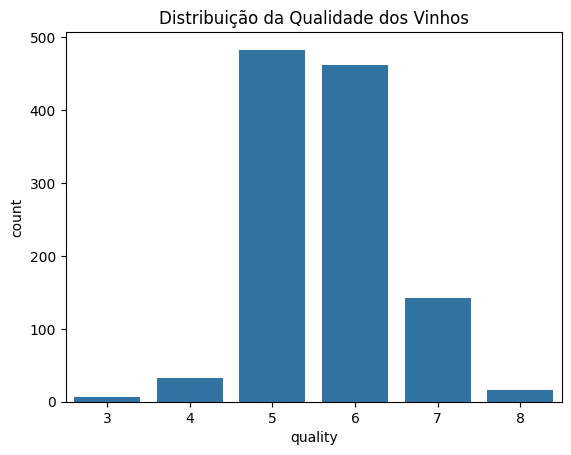

In [30]:
# Distribuição das notas de qualidade dos vinhos
sns.countplot(x='quality', data=df)
plt.title('Distribuição da Qualidade dos Vinhos')
plt.show()

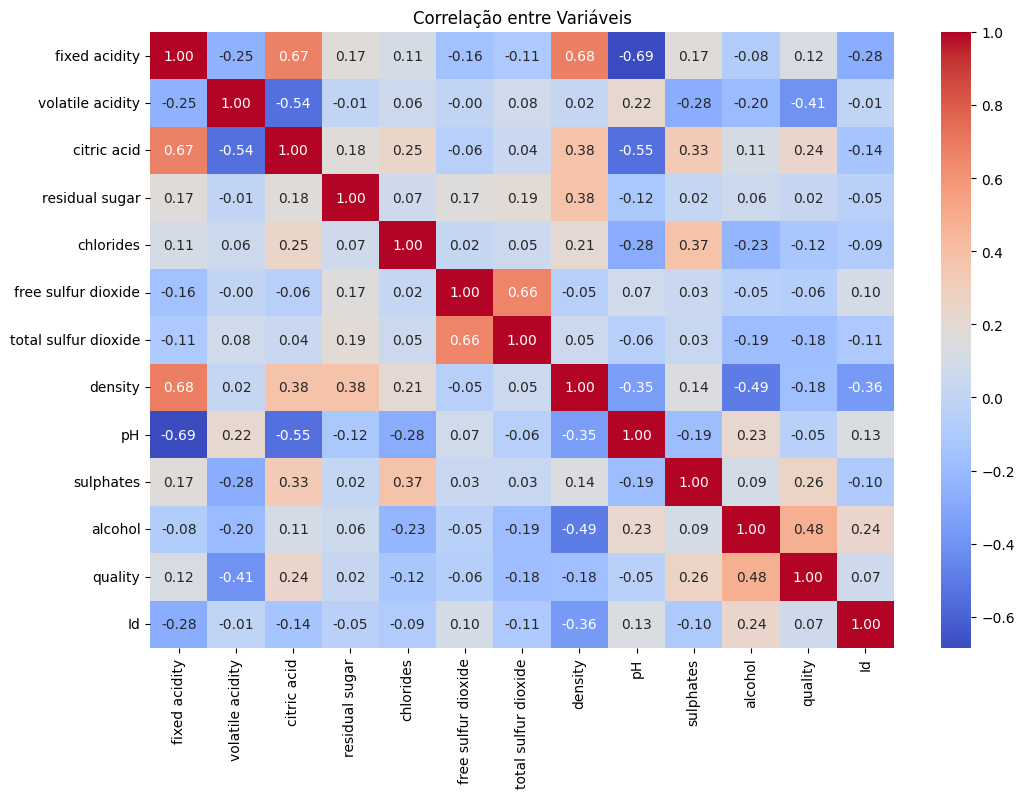

In [31]:
# Heatmap de correlação entre as variáveis
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlação entre Variáveis')
plt.show()

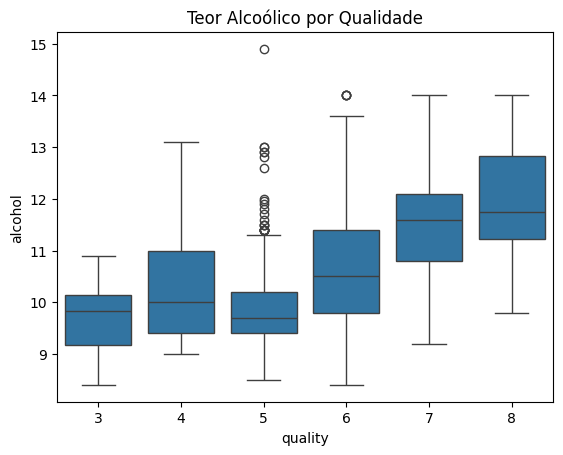

In [32]:
# Boxplot comparando teor alcoólico por qualidade
sns.boxplot(x='quality', y='alcohol', data=df)
plt.title('Teor Alcoólico por Qualidade')
plt.show()

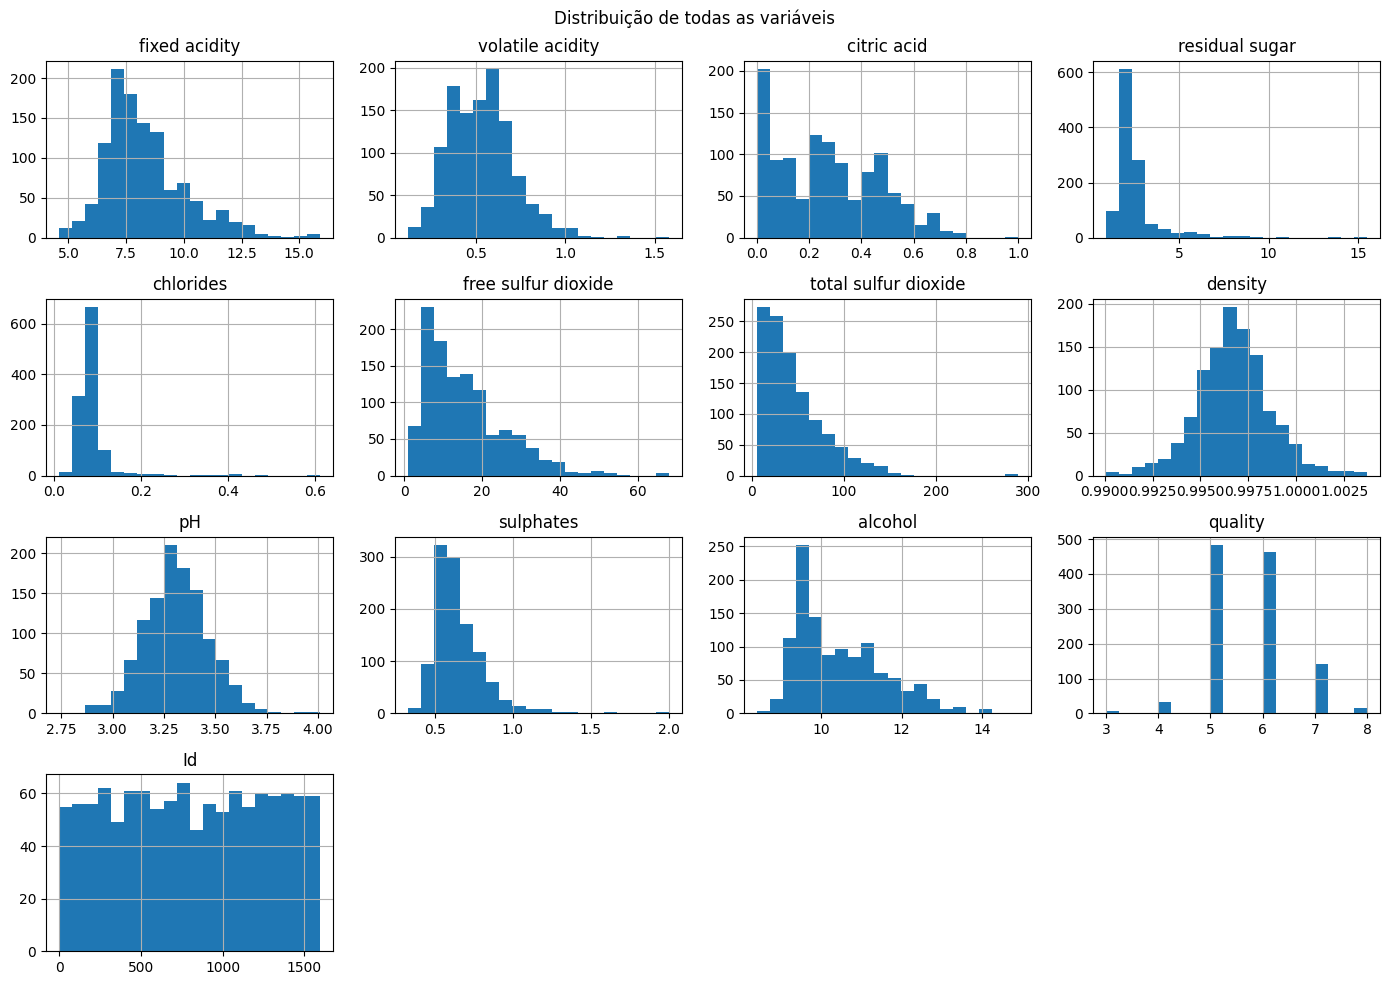

In [33]:
# Distribuição de cada variável
df.hist(figsize=(14, 10), bins=20)
plt.suptitle('Distribuição de todas as variáveis')
plt.tight_layout()
plt.show()

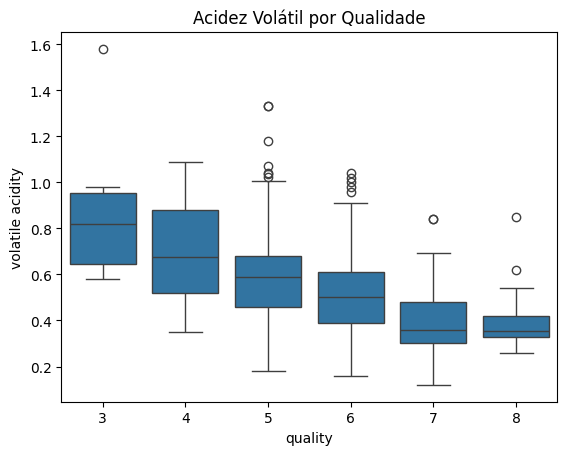

In [34]:
# Comparando acidez volátil por qualidade
sns.boxplot(x='quality', y='volatile acidity', data=df)
plt.title('Acidez Volátil por Qualidade')
plt.show()


Vinhos de menor qualidade (notas 3 e 4) apresentam maior acidez volátil, enquanto vinhos de alta qualidade (notas 7 e 8) têm acidez volátil significativamente menor. Isso indica que a acidez volátil tem relação inversa com a qualidade do vinho — quanto maior a acidez volátil, pior tende ser o vinho.

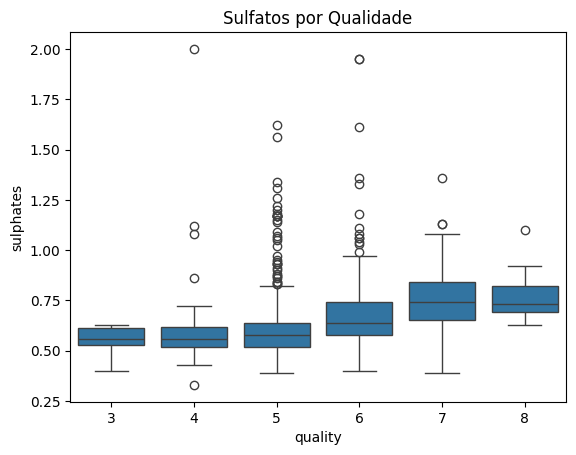

In [35]:
# Comparando sulfatos por qualidade
sns.boxplot(x='quality', y='sulphates', data=df)
plt.title('Sulfatos por Qualidade')
plt.show()

Análise dos Sulfatos por Qualidade:
Vinhos de alta qualidade (notas 7 e 8) apresentam níveis de sulfatos consistentemente mais altos em comparação com vinhos de baixa qualidade. Isso sugere que os sulfatos têm relação positiva com a qualidade — vinhos melhores tendem a ter mais sulfatos.

Para simplificar o problema, a variável quality foi transformada em uma classificação binária. Vinhos com nota ≥ 7 foram classificados como Alta Qualidade (1) e os demais como Baixa/Média Qualidade (0). A coluna quality original foi removida para evitar vazamento de informação ao modelo.

In [36]:
# Criando a variável alvo binária
# Vinho de Alta Qualidade = nota >= 7 (1)
# Vinho de Baixa/Média Qualidade = nota < 7 (0)
df['high_quality'] = (df['quality'] >= 7).astype(int)

# Removendo a coluna quality original para não vazar informação pro modelo
df = df.drop('quality', axis=1)

# Confirmando o balanceamento das classes
print('Balanceamento das classes:')
print(df['high_quality'].value_counts())

# Visualizando como ficou o dataframe
df.head()

Balanceamento das classes:
high_quality
0    984
1    159
Name: count, dtype: int64


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id,high_quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,1,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,2,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,3,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,4,0


In [37]:
df['high_quality'].value_counts()

,count
high_quality,
0,984
1,159


Os dados foram divididos em treino (80%) e teste (20%). O parâmetro stratify garante que a proporção das classes seja mantida em ambos os conjuntos. Em seguida, foi aplicada a padronização com StandardScaler nas features para garantir que todas as variáveis estejam na mesma escala.

In [38]:
# Separando features (X) e target (y)
X = df.drop('high_quality', axis=1)
y = df['high_quality']

# Dividindo em treino (80%) e teste (20%)
# stratify=y garante que a proporção das classes seja mantida igual no treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Treino: {X_train.shape[0]} amostras')
print(f'Teste: {X_test.shape[0]} amostras')

# Aplicando padronização
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print('Pré-processamento concluído!')

Treino: 914 amostras
Teste: 229 amostras
Pré-processamento concluído!


Foram treinados dois modelos de classificação para comparação: Regressão Logística, como modelo baseline por sua simplicidade e interpretabilidade, e Random Forest, um modelo mais robusto baseado em ensemble de árvores de decisão

In [39]:
# Treinando a Regressão Logística
modelo_lr = LogisticRegression(random_state=42, class_weight='balanced')
modelo_lr.fit(X_train, y_train)
y_pred_lr = modelo_lr.predict(X_test)

print('Regressão Logística treinada!')

Regressão Logística treinada!


In [40]:
# Treinando o Random Forest
modelo_rf = RandomForestClassifier(random_state=42, class_weight='balanced')
modelo_rf.fit(X_train, y_train)
y_pred_rf = modelo_rf.predict(X_test)

print('Random Forest treinado!')

Random Forest treinado!


In [41]:
# Avaliação da Regressão Logística
print('=== Regressão Logística ===')
print(f'Acurácia: {accuracy_score(y_test, y_pred_lr):.2f}')
print(classification_report(y_test, y_pred_lr, target_names=['Baixa/Média Qualidade', 'Alta Qualidade']))

=== Regressão Logística ===
Acurácia: 0.81
                       precision    recall  f1-score   support

Baixa/Média Qualidade       0.95      0.82      0.88       197
       Alta Qualidade       0.40      0.72      0.51        32

             accuracy                           0.81       229
            macro avg       0.67      0.77      0.70       229
         weighted avg       0.87      0.81      0.83       229



In [42]:
# Avaliação do Random Forest
print('=== Random Forest ===')
print(f'Acurácia: {accuracy_score(y_test, y_pred_rf):.2f}')
print(classification_report(y_test, y_pred_rf, target_names=['Baixa/Média Qualidade', 'Alta Qualidade']))

=== Random Forest ===
Acurácia: 0.91
                       precision    recall  f1-score   support

Baixa/Média Qualidade       0.92      0.97      0.95       197
       Alta Qualidade       0.76      0.50      0.60        32

             accuracy                           0.91       229
            macro avg       0.84      0.74      0.78       229
         weighted avg       0.90      0.91      0.90       229



O Random Forest apresentou desempenho superior à Regressão Logística em todas as métricas avaliadas. Com acurácia de 91% contra 81%, e F1-Score de 0.60 contra 0.51 para vinhos de alta qualidade, o Random Forest se mostrou o modelo mais adequado para este problema.

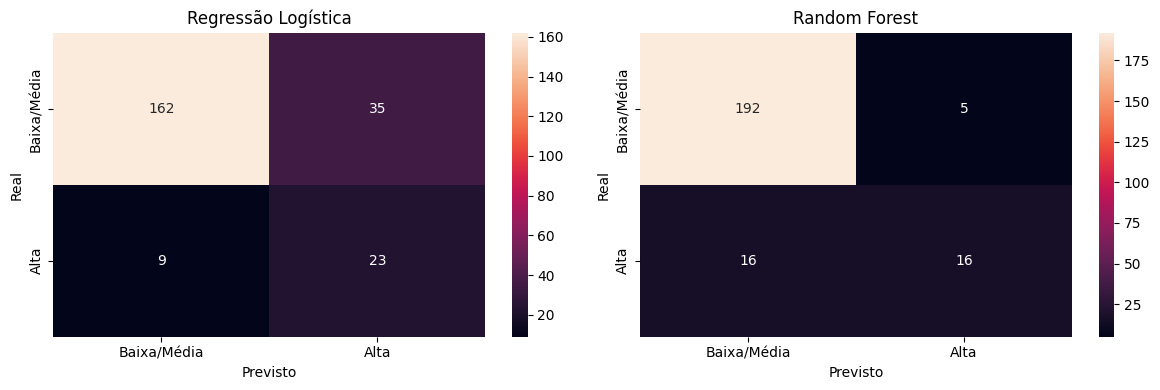

In [43]:
# Matriz de confusão dos dois modelos
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', ax=axes[0],
            xticklabels=['Baixa/Média', 'Alta'], yticklabels=['Baixa/Média', 'Alta'])
axes[0].set_title('Regressão Logística')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Previsto')

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', ax=axes[1],
            xticklabels=['Baixa/Média', 'Alta'], yticklabels=['Baixa/Média', 'Alta'])
axes[1].set_title('Random Forest')
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Previsto')

plt.tight_layout()
plt.show()

O Random Forest errou muito menos na classe Baixa/Média (apenas 5 erros contra 35 da Regressão Logística), porém ambos os modelos ainda têm dificuldade em identificar vinhos de Alta Qualidade, reflexo do desbalanceamento das classes no dataset.

O Random Forest permite extrair a importância de cada variável na tomada de decisão do modelo, auxiliando na interpretação dos resultados e na identificação dos fatores que mais influenciam a qualidade do vinho

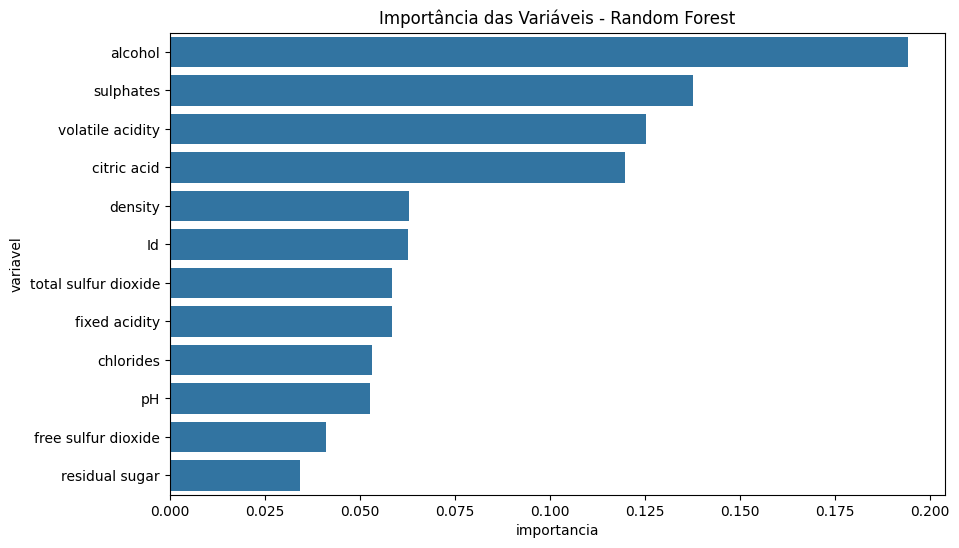

                variavel  importancia
10               alcohol     0.194084
9              sulphates     0.137535
1       volatile acidity     0.125136
2            citric acid     0.119652
7                density     0.062996
11                    Id     0.062652
6   total sulfur dioxide     0.058436
0          fixed acidity     0.058368
4              chlorides     0.053270
8                     pH     0.052564
5    free sulfur dioxide     0.041085
3         residual sugar     0.034221


In [44]:
# Importância das variáveis no Random Forest
importancias = pd.DataFrame({
    'variavel': X.columns,
    'importancia': modelo_rf.feature_importances_
}).sort_values('importancia', ascending=False)

# Gráfico
plt.figure(figsize=(10, 6))
sns.barplot(x='importancia', y='variavel', data=importancias)
plt.title('Importância das Variáveis - Random Forest')
plt.show()

print(importancias)

Conclusão

O modelo Random Forest demonstrou ser superior à Regressão Logística para este problema, atingindo 91% de acurácia contra 81%. As variáveis com maior influência na qualidade do vinho foram o teor alcoólico, os sulfatos e a acidez volátil — resultados que confirmam os insights identificados durante a análise exploratória.

O principal desafio encontrado foi o desbalanceamento das classes, com apenas 14% dos vinhos classificados como alta qualidade